#Day27. 머신러닝기초
---

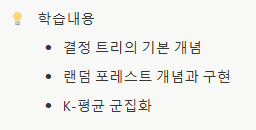

# **ANN (Artificial Neural Network)**

인공신경망(Artificial Neural Network, ANN)은 인간의 뇌 구조를 모방한 기계 학습 모델  
주로 패턴 인식, 분류, 예측 등의 문제 해결에 사용됨

####**Single Layer Perceptron (SLP)**

In [1]:
import numpy as np

# 시그모이드 활성화 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# SLP 구현 (하드 코딩된 가중치와 편향)
def forward_slp(X, W, b):
    Z = np.dot(W, X) + b  # 선형 변환
    A = sigmoid(Z)  # 시그모이드 활성화 함수 적용
    return A

# 입력 데이터 예시 (특징 3개)
X = np.array([[1], [2], [3]])  # 입력 데이터

# 하드코딩된 가중치와 편향
W = np.array([[0.2, 0.4, 0.6]])  # 1x3 크기 (하나의 노드)
b = np.array([[0.5]])  # 편향

# SLP 순전파
output_slp = forward_slp(X, W, b)

print("Single Layer Perceptron 출력:", output_slp)

Single Layer Perceptron 출력: [[0.96442881]]


#### **Multi-Layer Perceptron (MLP)**

In [2]:
# ReLU 활성화 함수
def relu(z):
    return np.maximum(0, z)

# 소프트맥스 함수
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # 안정성을 위한 처리
    return exp_z / np.sum(exp_z, axis=0)

# MLP 구현 (하드 코딩된 가중치와 편향)
def forward_mlp(X, parameters):
    # 첫 번째 은닉층
    W1 = parameters['W1']
    b1 = parameters['b1']
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # 출력층
    W2 = parameters['W2']
    b2 = parameters['b2']
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    return A2

# 입력 데이터 예시 (특징 3개)
X = np.array([[1], [2], [3]])  # 입력 데이터

# 하드코딩된 가중치와 편향
parameters = {
    'W1': np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9], [1.0, 1.1, 1.2]]),  # 은닉층 가중치 (4x3)
    'b1': np.array([[0.1], [0.2], [0.3], [0.4]]),  # 은닉층 편향 (4x1)
    'W2': np.array([[0.1, 0.2, 0.3, 0.4], [0.5, 0.6, 0.7, 0.8]]),  # 출력층 가중치 (2x4)
    'b2': np.array([[0.1], [0.2]])  # 출력층 편향 (2x1)
}

# MLP 순전파
output_mlp = forward_mlp(X, parameters)

print("Multi-Layer Perceptron 출력:", output_mlp)

Multi-Layer Perceptron 출력: [[8.58041227e-04]
 [9.99141959e-01]]


1. **Single Layer Perceptron (SLP)**:
    - 입력 데이터  X = [1, 2, 3] 에 대해 하드코딩된 가중치 W = [0.2, 0.4, 0.6] 와 편향  b = 0.5 을 적용하여 선형 변환 수행
    - 시그모이드 활성화 함수로 출력값 계산
2. **Multi-Layer Perceptron (MLP)**:
    - 하드코딩된 가중치와 편향 사용
        - 첫 번째 은닉층 가중치  W1 는 4개의 뉴런이므로 4x3 크기, 편향   b1 는 4x1 크기
        - 출력층 가중치  W2 는 2개의 출력 뉴런이므로 2x4 크기, 편향  b2 는 2x1 크기
    - ReLU 활성화 함수를 은닉층에서 사용하고, 소프트맥스를 출력층에서 적용하여 각 클래스의 확률 반환
3. 요약
    - **SLP**: 이진 분류 문제에서 단순한 예측 결과 출력
    - **MLP**: 은닉층을 포함하여 더 복잡한 다중 클래스 분류 문제를 해결하는 구조



---

###**이론적 개념**

인공신경망은 여러 개의 **뉴런**(노드)이 레이어(층)로 배열된 구조로, 입력과 출력을 연결  
각 뉴런은 활성화 함수(activation function)를 통해 입력 신호를 처리하며, 가중치(weight)와 편향(bias)을 포함하여 학습 진행

### 주요 구성 요소:

- **입력층(Input Layer)**: 데이터가 처음 들어오는 층
- **은닉층(Hidden Layer)**: 입력층과 출력층 사이에 위치한 층으로, 이 층에서 중요한 특징 추출이 이루어짐
- **출력층(Output Layer)**: 최종 예측 결과가 나오는 층
- **가중치(Weights)**: 각 연결에서 신호의 중요도
- **편향(Bias)**: 뉴런 활성화에 영향을 미치는 추가적인 요소

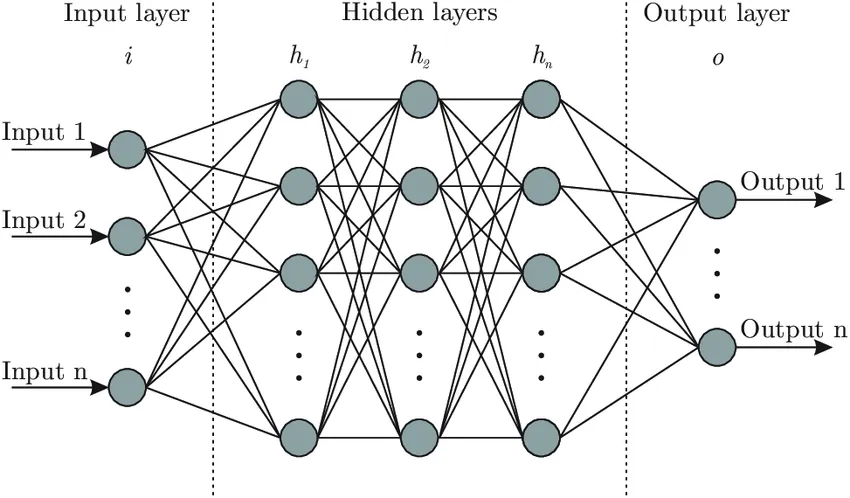

###**다층 신경망에 대한 구성**

1. **기본 구성**

- 입력 벡터  $\mathbf{x} \in \mathbb{R}^n$
- 첫 번째 은닉층의 가중치 행렬 $\mathbf{W}^{(1)} \in \mathbb{R}^{m_1 \times n}$ 와 편향  $\mathbf{b}^{(1)} \in \mathbb{R}^{m_1}$
- 두 번째 은닉층의 가중치 행렬  $\mathbf{W}^{(2)} \in \mathbb{R}^{m_2 \times m_1}$ 와 편향  $\mathbf{b}^{(2)} \in \mathbb{R}^{m_2}$
- 최종 출력층의 가중치 행렬  $\mathbf{W}^{(3)} \in \mathbb{R}^{c \times m_2}$ 와 편향  $\mathbf{b}^{(3)} \in \mathbb{R}^{c}$
- $c$ 는 클래스의 수 (출력 차원),  $m_1, m_2$ 는 은닉층의 뉴런 수

2. **수식 표현**

1) **첫 번째 은닉층**

첫 번째 은닉층에서 입력  $\mathbf{x}$ 에 대해 가중치  $\mathbf{W}^{(1)}$ 와 편향 $\mathbf{b}^{(1)}$ , 그리고 활성화 함수  $f_1$  적용

$$
\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}
$$

$$
\mathbf{a}^{(1)} = f_1(\mathbf{z}^{(1)})
$$

여기서 $\mathbf{z}^{(1)}$ 은 가중합, $\mathbf{a}^{(1)}$ 는 첫 번째 은닉층의 출력

2) **두 번째 은닉층**

첫 번째 은닉층의 출력 $\mathbf{a}^{(1)}$ 을 입력으로 받아 두 번째 은닉층에서 가중치 $\mathbf{W}^{(2)}$ , 편향$\mathbf{b}^{(2)}$ , 그리고 활성화 함수 $f_2$ 가 적용

$$
\mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}
$$

$$
\mathbf{a}^{(2)} = f_2(\mathbf{z}^{(2)})
$$

3) **출력층**

두 번째 은닉층의 출력  $\mathbf{a}^{(2)}$ 을 입력으로 받아 출력층에서 가중치  $\mathbf{W}^{(3)}$ , 편향 $\mathbf{b}^{(3)}$ 가 적용된 후, 최종적으로 **소프트맥스(Softmax)** 함수가 적용

먼저, 출력층의 가중합은 다음과 같음:

$$
\mathbf{z}^{(3)} = \mathbf{W}^{(3)} \mathbf{a}^{(2)} + \mathbf{b}^{(3)}
$$

그 후, **소프트맥스 함수**를 적용하여 각 클래스에 대한 확률을 구함:

$$
\hat{\mathbf{y}} = \text{softmax}(\mathbf{z}^{(3)}) = \frac{\exp(\mathbf{z}^{(3)})}{\sum_{j=1}^{c} \exp(z_j^{(3)})}
$$

여기서 $\hat{\mathbf{y}}$ 는 클래스에 대한 확률 벡터이며,  $z_j^{(3)}$ 는 출력층에서 각 클래스  $j$ 에 대한 가중합

3. **최종 모델의 표현**

다층 신경망의 전체 과정을 하나의 수식으로 나타내면 다음과 같음:

$$
\hat{\mathbf{y}} = \text{softmax} \left( \mathbf{W}^{(3)} f_2 \left( \mathbf{W}^{(2)} f_1 \left( \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \right) + \mathbf{b}^{(2)} \right) + \mathbf{b}^{(3)} \right)
$$

이 식은 입력  $\mathbf{x}$ 가 각 은닉층을 거쳐 활성화 함수를 통과하고, 최종적으로 소프트맥스 함수에 의해 확률로 변환되는 과정을 수식으로 나타낸 것

### summary …

- 첫 번째 은닉층:  $\mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}, \mathbf{a}^{(1)} = f_1(\mathbf{z}^{(1)})$
- 두 번째 은닉층:   $\mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}, \mathbf{a}^{(2)} = f_2(\mathbf{z}^{(2)})$
- 출력층:  $\mathbf{z}^{(3)} = \mathbf{W}^{(3)} \mathbf{a}^{(2)} + \mathbf{b}^{(3)}$
- 최종 확률 출력: $\hat{\mathbf{y}} = \text{softmax}(\mathbf{z}^{(3)})$

이를 통해 다층 신경망에서 각 층마다 활성화 함수가 적용되고, 최종적으로 소프트맥스가 확률 출력으로 변환.

### 3. **수식 표현**

신경망은 각 뉴런에서 다음과 같은 연산을 수행:

1. **입력과 가중치의 곱**을 계산한 뒤, **편향**을 더해줌
    
  $
  z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
  $
    
    여기서  $x_1, x_2, ..., x_n$ 은 입력, $w_1, w_2, ..., w_n$ 은 가중치,  $b$ 는 편향을 나타냄
    
2. 그런 다음, **활성화 함수** 적용  
활성화 함수는 뉴런의 출력이 어느 범위 내에 있도록 제한하며, 비선형성 부여
    
    예를 들어, **시그모이드(Sigmoid)** 함수는 다음과 같이 정의:
    
  $
  a = \frac{1}{1 + e^{-z}}
  $
    
    또 다른 활성화 함수인 ReLU(Rectified Linear Unit)는 다음과 같음:
    
  $
  a = \max(0, z)
  $
    
3. **오차 역전파(Backpropagation)**: 신경망을 학습시키는 과정에서, 출력과 실제 값 사이의 **오차**를 기반으로 가중치와 편향을 업데이트하는 과정  
이를 위해 기울기 하강법(Gradient Descent)이 사용됨
    
    손실 함수(Loss function)의 값에 따라 다음과 같이 가중치가 업데이트됨:
    
  $
  w = w - \eta \frac{\partial L}{\partial w}
  $
    
    여기서  $\eta$ 는 학습률(Learning Rate),  $L$ 은 손실 함수,  $w$ 는 가중치

In [3]:
import numpy as np

# 활성화 함수 (sigmoid) 및 그 도함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# 손실 함수 (Mean Squared Error)
def loss(y_true, y_pred):
    return 0.5 * np.mean((y_true - y_pred) ** 2)

# 데이터 (입력과 실제 출력)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # 입력 (XOR 문제)
y = np.array([[0], [1], [1], [0]])              # 실제 출력

# 가중치 및 편향 초기화 (무작위)
W1 = np.random.randn(2, 2)  # 입력층 -> 은닉층 가중치
b1 = np.random.randn(1, 2)  # 은닉층 편향
W2 = np.random.randn(2, 1)  # 은닉층 -> 출력층 가중치
b2 = np.random.randn(1, 1)  # 출력층 편향

# 학습률 설정
learning_rate = 0.1

# 순전파 및 역전파 실행
for epoch in range(10000):  # 10,000번 반복 학습
    # 순전파 (Forward Propagation)
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)  # 예측 출력

    # 손실 계산
    loss_value = loss(y, a2)

    # 역전파 (Backpropagation)
    # 출력층 오차
    dL_da2 = a2 - y  # 손실의 출력층에 대한 기울기
    dL_dz2 = dL_da2 * sigmoid_derivative(z2)

    # 은닉층 -> 출력층 가중치 및 편향 업데이트
    dL_dW2 = np.dot(a1.T, dL_dz2)
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

    # 은닉층 오차
    dL_da1 = np.dot(dL_dz2, W2.T)
    dL_dz1 = dL_da1 * sigmoid_derivative(z1)

    # 입력층 -> 은닉층 가중치 및 편향 업데이트
    dL_dW1 = np.dot(X.T, dL_dz1)
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # 가중치 및 편향 업데이트
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss_value}')

# 최종 예측 값 출력
print("Final predictions:")
print(a2)

Epoch 0, Loss: 0.13414184490682818
Epoch 1000, Loss: 0.12514973456010026
Epoch 2000, Loss: 0.1244306948409151
Epoch 3000, Loss: 0.11840873282269535
Epoch 4000, Loss: 0.09333335024447217
Epoch 5000, Loss: 0.07558889089818202
Epoch 6000, Loss: 0.06938511301148727
Epoch 7000, Loss: 0.06690510328884682
Epoch 8000, Loss: 0.06566557928613152
Epoch 9000, Loss: 0.06494321907319903
Final predictions:
[[0.04977623]
 [0.49814648]
 [0.93612793]
 [0.50734994]]


- **sigmoid 함수**: 은닉층과 출력층에서 사용하는 활성화 함수
- **순전파**: 입력 데이터를 신경망을 통해 전달하여 예측값 계산
- **역전파**: 출력과 실제 값의 차이로부터 가중치에 대한 기울기 계산, 이를 사용해 가중치 업데이트
- **경사하강법**: 학습률에 따라 가중치를 수정하여 손실을 줄여 나감.

이 코드는 XOR 문제를 해결하기 위한 간단한 신경망이며, 각 에포크(epoch)마다 가중치가 업데이트되어 손실(loss) 감소

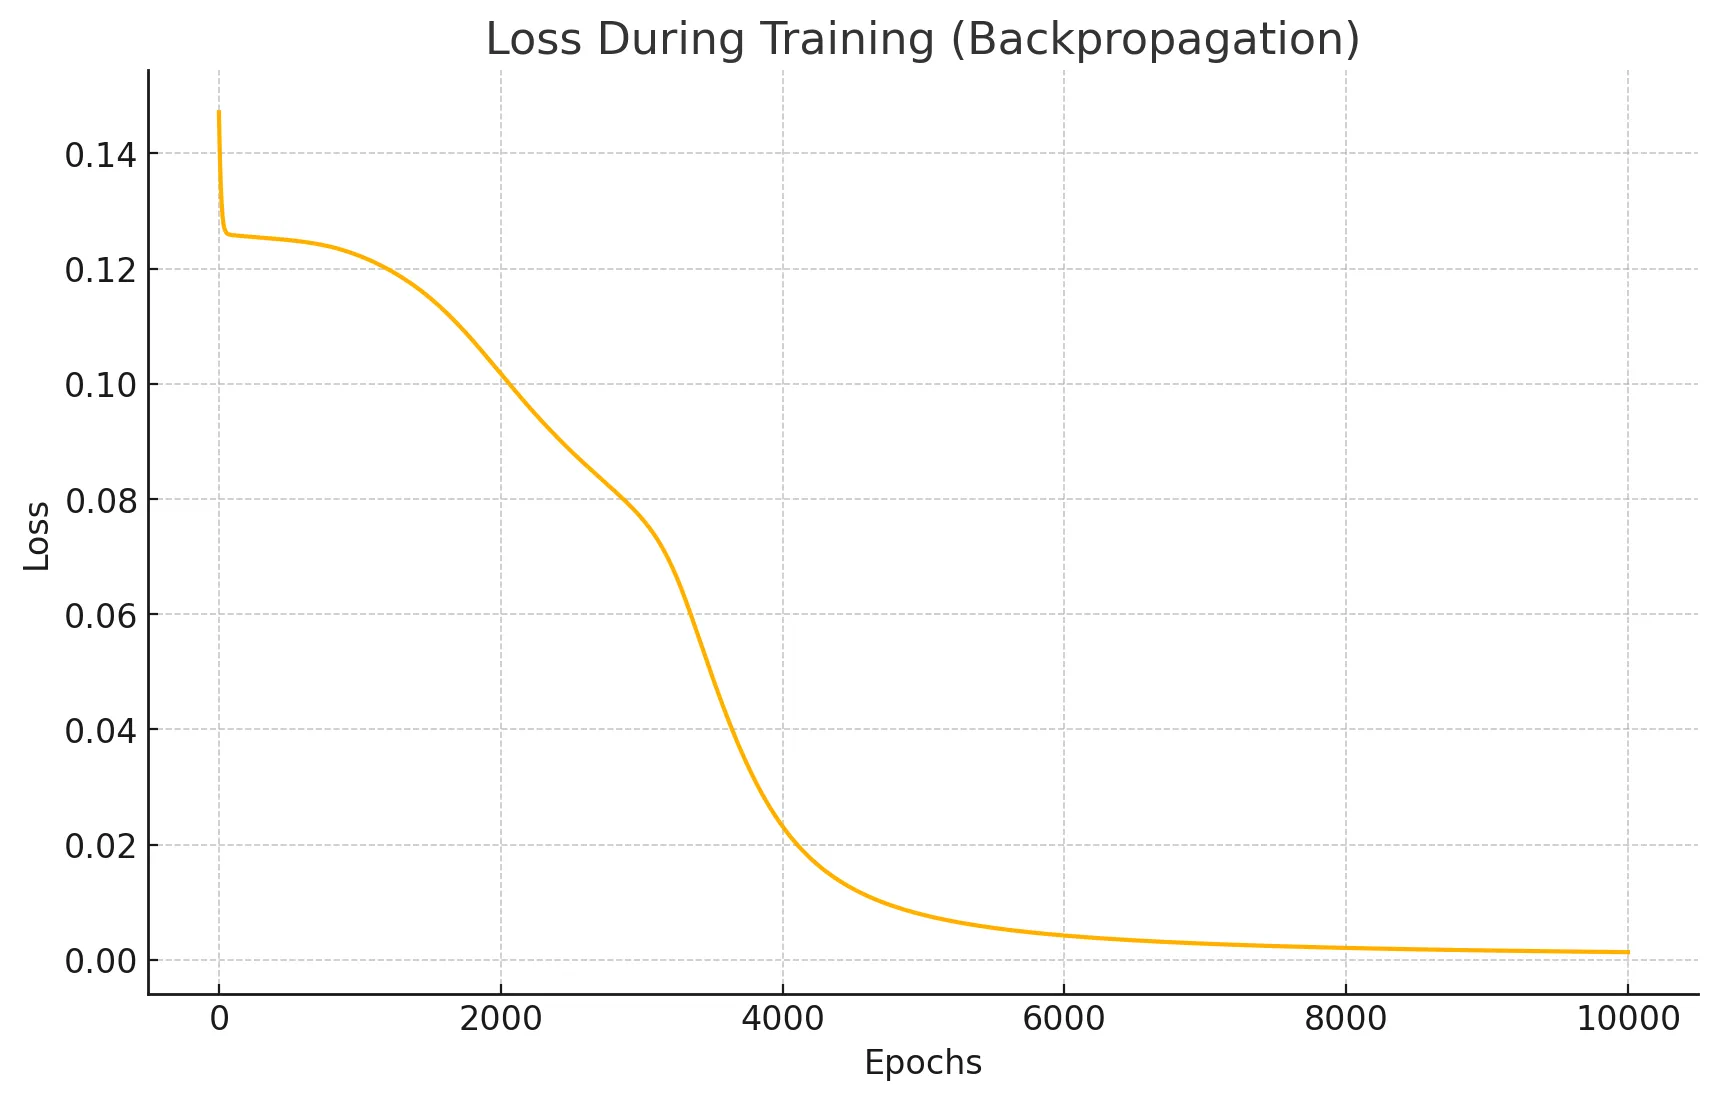



---

### **코드 표현**

1. **필요한 라이브러리 불러오기**

```python
import numpy as np
```

2. **활성화 함수 정의**

은닉층에서 주로 사용되는 활성화 함수인 **ReLU**와 출력층에 적용되는 **소프트맥스** 함수를 정의합니다.

```python
# ReLU 활성화 함수 정의
def relu(z):
    return np.maximum(0, z)

# 소프트맥스 함수 정의
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # Overflow 방지를 위해 최대값을 뺌
    return exp_z / np.sum(exp_z, axis=0)
```

3. **신경망 가중치 초기화**

가중치   $\mathbf{W}$ 와 편향  $\mathbf{b}$ 를 초기화합니다. 랜덤 초기화를 사용합니다.

```python
# 가중치 및 편향 초기화 함수 (랜덤)
def initialize_parameters(layer_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)  # 층의 개수

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters
```

`layer_dims`는 각 층의 뉴런 수를 정의한 리스트입니다. 예를 들어, 입력층 3개 뉴런, 첫 번째 은닉층 4개 뉴런, 두 번째 은닉층 5개 뉴런, 출력층 3개 뉴런이라면 `layer_dims = [3, 4, 5, 3]`로 설정합니다.

4. **순전파 (Forward Propagation) 구현**

입력 데이터에 대해 순전파 과정을 구현합니다. 각 은닉층에서는 가중합을 계산하고 활성화 함수를 적용합니다. 최종 출력층에서는 소프트맥스를 적용하여 확률을 반환합니다.

```python
def forward_propagation(X, parameters):
    # 첫 번째 은닉층
    W1 = parameters['W1']
    b1 = parameters['b1']
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # 두 번째 은닉층
    W2 = parameters['W2']
    b2 = parameters['b2']
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # 출력층
    W3 = parameters['W3']
    b3 = parameters['b3']
    Z3 = np.dot(W3, A2) + b3
    A3 = softmax(Z3)  # 소프트맥스 적용

    return A3
```

여기서:

- `X`는 입력 데이터(특징 벡터)입니다.
- `Z1`, `Z2`, `Z3`는 각 층에서의 가중합을 의미합니다.
- `A1`, `A2`, `A3`는 각 층의 활성화 함수의 출력을 의미합니다.

5. **사용 예시**

다음은 신경망의 각 층을 정의하고, 데이터를 입력하여 순전파를 수행하는 과정을 설명합니다.

```python
# 입력 데이터 예시 (특징 수 3, 샘플 수 1)
X = np.array([[1], [2], [3]])

# 각 층의 뉴런 수를 정의 (입력층 3개, 은닉층 4개, 5개, 출력층 3개)
layer_dims = [3, 4, 5, 3]

# 가중치 및 편향 초기화
parameters = initialize_parameters(layer_dims)

# 순전파 실행
output = forward_propagation(X, parameters)

# 출력 결과
print("Softmax 확률 출력:", output)
```

6. **통합 코드**

In [4]:
import numpy as np

# ReLU 활성화 함수 정의
def relu(z):
    return np.maximum(0, z)

# 소프트맥스 함수 정의
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # Overflow 방지를 위해 최대값을 뺌
    return exp_z / np.sum(exp_z, axis=0)

# 가중치 및 편향 초기화 함수 (랜덤)
def initialize_parameters(layer_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)  # 층의 개수

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

# 순전파 (Forward Propagation) 구현
def forward_propagation(X, parameters):
    # 첫 번째 은닉층
    W1 = parameters['W1']
    b1 = parameters['b1']
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # 두 번째 은닉층
    W2 = parameters['W2']
    b2 = parameters['b2']
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # 출력층
    W3 = parameters['W3']
    b3 = parameters['b3']
    Z3 = np.dot(W3, A2) + b3
    A3 = softmax(Z3)  # 소프트맥스 적용

    return A3

# 사용 예시

# 입력 데이터 예시 (특징 수 3, 샘플 수 1)
X = np.array([[1], [2], [3]])

# 각 층의 뉴런 수를 정의 (입력층 3개, 은닉층 4개, 5개, 출력층 3개)
layer_dims = [3, 4, 5, 3]

# 가중치 및 편향 초기화
parameters = initialize_parameters(layer_dims)

# 순전파 실행
output = forward_propagation(X, parameters)

# 출력 결과
print("Softmax 확률 출력:", output)

Softmax 확률 출력: [[0.33333293]
 [0.33333388]
 [0.3333332 ]]


**다층신경망을 적용한 매출예측**

In [5]:
import numpy as np

# ReLU 활성화 함수 정의
def relu(z):
    return np.maximum(0, z)

# ReLU 미분 함수 (Backpropagation에서 사용)
def relu_derivative(z):
    return np.where(z > 0, 1, 0)

# 손실 함수 (Mean Squared Error)
def compute_loss(Y, A):
    m = Y.shape[1]  # 샘플 수
    loss = np.mean((Y - A) ** 2)  # MSE 계산
    return loss

# 가중치 및 편향 초기화 함수
def initialize_parameters(layer_dims):
    np.random.seed(1)
    parameters = {}

    for l in range(1, len(layer_dims)):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

# 순전파 (Forward Propagation)
def forward_propagation(X, parameters):
    cache = {}

    # 첫 번째 은닉층
    W1 = parameters['W1']
    b1 = parameters['b1']
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # 두 번째 은닉층
    W2 = parameters['W2']
    b2 = parameters['b2']
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # 출력층 (회귀 문제이므로 활성화 함수 없음)
    W3 = parameters['W3']
    b3 = parameters['b3']
    Z3 = np.dot(W3, A2) + b3
    A3 = Z3  # 출력층 활성화 함수는 사용하지 않음

    # 캐시 저장 (역전파에서 사용)
    cache['Z1'], cache['A1'] = Z1, A1
    cache['Z2'], cache['A2'] = Z2, A2
    cache['Z3'], cache['A3'] = Z3, A3

    return A3, cache

# 역전파 (Backward Propagation)
def backward_propagation(X, Y, parameters, cache):
    m = X.shape[1]  # 샘플 수
    grads = {}

    # 출력층 오차
    A3 = cache['A3']
    dZ3 = A3 - Y
    grads['dW3'] = np.dot(dZ3, cache['A2'].T) / m
    grads['db3'] = np.sum(dZ3, axis=1, keepdims=True) / m

    # 두 번째 은닉층 오차
    dA2 = np.dot(parameters['W3'].T, dZ3)
    dZ2 = dA2 * relu_derivative(cache['Z2'])
    grads['dW2'] = np.dot(dZ2, cache['A1'].T) / m
    grads['db2'] = np.sum(dZ2, axis=1, keepdims=True) / m

    # 첫 번째 은닉층 오차
    dA1 = np.dot(parameters['W2'].T, dZ2)
    dZ1 = dA1 * relu_derivative(cache['Z1'])
    grads['dW1'] = np.dot(dZ1, X.T) / m
    grads['db1'] = np.sum(dZ1, axis=1, keepdims=True) / m

    return grads

# 파라미터 업데이트 (경사 하강법)
def update_parameters(parameters, grads, learning_rate):
    for l in range(1, len(parameters) // 2 + 1):
        parameters['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
        parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]

    return parameters

# 학습 데이터 생성 (하드코딩된 연도별 매출 데이터)
X_train = np.array([[2017, 2018, 2019, 2020, 2021]])  # 연도
Y_train = np.array([[100, 150, 200, 250, 300]])  # 해당 연도의 매출

# 데이터 정규화
X_train = X_train / 2021  # 연도를 최대값으로 나누어 정규화
Y_train = Y_train / 300  # 매출도 최대값으로 나누어 정규화

# 레이어 구성 (입력층 1, 은닉층 2개, 출력층 1개)
layer_dims = [1, 5, 3, 1]

# 파라미터 초기화
parameters = initialize_parameters(layer_dims)

# 학습 하이퍼파라미터
learning_rate = 0.01
num_iterations = 10000

# 학습 과정
for i in range(num_iterations):
    # 순전파
    A3, cache = forward_propagation(X_train, parameters)

    # 손실 계산
    loss = compute_loss(Y_train, A3)

    # 역전파
    grads = backward_propagation(X_train, Y_train, parameters, cache)

    # 파라미터 업데이트
    parameters = update_parameters(parameters, grads, learning_rate)

    # 1000번마다 손실 출력
    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {loss:.4f}")

# 테스트 데이터 예측
X_test = np.array([[2022]])  # 테스트 데이터 (2022년)
X_test = X_test / 2021  # 정규화

# 순전파로 예측
A3_test, _ = forward_propagation(X_test, parameters)

# 예측 결과 출력 (2022년 매출 예측)
print("2022년 매출 예측 (원래 값):", A3_test * 300)  # 원래 단위로 변환

Iteration 0, Loss: 0.5000
Iteration 1000, Loss: 0.0556
Iteration 2000, Loss: 0.0556
Iteration 3000, Loss: 0.0556
Iteration 4000, Loss: 0.0556
Iteration 5000, Loss: 0.0556
Iteration 6000, Loss: 0.0556
Iteration 7000, Loss: 0.0556
Iteration 8000, Loss: 0.0556
Iteration 9000, Loss: 0.0556
2022년 매출 예측 (원래 값): [[200.00000233]]


**신경망과 심층신경망의 차이**

신경망(Neural Network)과 심층 신경망(Deep Neural Network, DNN)의 차이는 주로 네트워크의 구조와 복잡성에 있음
이 두 개념은 기본적으로 동일한 신경망 원리에 기반하지만, 은닉층(hidden layers)의 수에 따라 구분됨

1. 신경망(Neural Network)
- 구조: 신경망은 기본적으로 입력층(input layer), 은닉층(hidden layer), 출력층(output layer)으로 구성  
이때 은닉층이 한 개이거나 없는 경우를 신경망이라고 함
- 특징:
    - 입력 데이터를 은닉층을 거쳐 출력층으로 전달
    - 가장 간단한 형태의 신경망으로는 퍼셉트론(Perceptron)이 있음  
    퍼셉트론은 은닉층 없이 바로 입력층에서 출력층으로 신호를 전달하는 단층 신경망(Single Layer Perceptron)
    - 한 개의 은닉층만을 가지는 다층 퍼셉트론(Multi-Layer Perceptron, MLP)도 일반 신경망으로 볼 수 있음
- 장점:
    - 구현이 상대적으로 간단하며, 빠르게 계산.
    - 단순한 문제나 선형적으로 구분 가능한 문제에 적합
- 단점:
    - 복잡한 문제(예: 이미지 인식, 자연어 처리)에서는 성능 제한적
    - 충분한 표현력을 가지지 못해 고차원의 패턴을 학습하는 데 어려움.
1. 심층 신경망(Deep Neural Network, DNN)
- 구조: 심층 신경망은 여러 개의 은닉층을 가지는 신경망을 의미  
일반적으로 3개 이상의 은닉층을 가진 신경망을 심층 신경망이라고 함
- 특징:
    - 은닉층의 수가 많아질수록 데이터의 복잡한 패턴을 더 잘 학습할 수 있음
    - 각 은닉층은 이전 층에서 입력받은 신호를 비선형 변환을 통해 다음 층으로 전달하면서 데이터를 점점 더 추상적인 수준으로 표현
    - 딥러닝(Deep Learning)이라는 용어는 심층 신경망을 이용한 학습 방법을 가리키며, 심층 신경망은 이미지 처리(CNN, Convolutional Neural Network), 시계열 데이터 처리(RNN, Recurrent Neural Network), 자연어 처리 등에 널리 사용됨
- 장점:
    - 복잡하고 비선형적인 데이터 패턴을 학습할 수 있음
    - 다층 구조를 통해 데이터의 더 높은 차원에서 의미 있는 피처(feature)를 추출할 수 있음
    - 이미지 인식, 음성 인식, 자연어 처리 등의 복잡한 문제를 해결하는 데 적합
- 단점:
    - 계산 비용이 매우 높고, 학습 시간이 오래 걸림
    - 많은 데이터와 높은 계산 능력을 필요로 함
    - 오버피팅(overfitting)의 위험이 있어 적절한 규제 기법(regularization) 필요

| 구분 | 신경망(Neural Network) | 심층 신경망(Deep Neural Network, DNN) |
| --- | --- | --- |
| 은닉층 | 1개 이하 | 여러 개(보통 3개 이상) |
| 복잡성 | 단순한 문제 해결 | 복잡한 문제 해결에 유리 |
| 표현력 | 제한적 | 고차원 패턴을 학습할 수 있음 |
| 계산 비용 | 낮음 | 매우 높음 |
| 학습 시간 | 짧음 | 길고 많은 데이터가 필요 |



---

### **5. 다층신경망 기반 분류모델 연습**

디렉토리 구조(on Google Colab)

```
content/
└── data/
    ├── dogs/
    │   ├── dog1.jpg
    │   ├── dog2.jpg
    │   └── ...
    └── cats/
        ├── cat1.jpg
        ├── cat2.jpg
        └── ...
```

- `dogs/` 폴더에는 개 이미지 파일, `cats/` 폴더에는 고양이 이미지 파일을 복사합니다.

[이미지데이터.zip](https://prod-files-secure.s3.us-west-2.amazonaws.com/2caac87b-5e53-4ec3-8c82-884c7e4c6365/3281951c-7385-45e5-8137-d326eb22efa4/%E1%84%8B%E1%85%B5%E1%84%86%E1%85%B5%E1%84%8C%E1%85%B5%E1%84%83%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A5.zip)

학습코드

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 경로 설정
base_dir = '/content/drive/MyDrive/data'  # 데이터 경로 설정

# 이미지 로드 및 전처리 (데이터 증강 없이)
train_datagen = ImageDataGenerator(
    rescale=1./255,        # 픽셀 값을 0-1 사이로 정규화
    validation_split=0.2   # 데이터의 20%를 검증용으로 분리
)

# 학습 데이터 로드
train_generator = train_datagen.flow_from_directory(
    base_dir,              # 데이터가 저장된 디렉토리
    target_size=(64, 64),  # 이미지 크기 조정
    batch_size=32,         # 배치 크기
    class_mode='binary',   # 이진 분류
    subset='training'      # 학습 데이터
)

# 검증 데이터 로드
validation_generator = train_datagen.flow_from_directory(
    base_dir,              # 데이터가 저장된 디렉토리
    target_size=(64, 64),  # 이미지 크기 조정
    batch_size=32,         # 배치 크기
    class_mode='binary',   # 이진 분류
    subset='validation'    # 검증 데이터
)

# 다층 신경망 모델 구성
model = Sequential()

# 입력 데이터를 평탄화 (Flatten)하여 1차원으로 변환
model.add(Flatten(input_shape=(64, 64, 3)))  # 이미지 크기가 64x64, RGB 채널 3개

# 은닉층 (뉴런 128개)
model.add(Dense(128, activation='relu'))

# 은닉층 (뉴런 64개)
model.add(Dense(64, activation='relu'))

# 출력층 (뉴런 1개, 시그모이드 활성화 함수 사용)
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일 (이진 분류, 손실 함수로 binary_crossentropy 사용)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,  # 에포크 수를 설정하여 학습 반복
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

# 모델 저장
model.save('dog_cat_classifier_mlp.h5')

# 테스트용 데이터로 예측
test_loss, test_acc = model.evaluate(validation_generator)
print(f"테스트 정확도: {test_acc}")

학습모델을 이용한 테스트 코드

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# 모델 로드
model = load_model('dog_cat_classifier_mlp.h5')

# 테스트 이미지 경로
test_image_path = '/content/data/dog/dog (1).jpeg'  # 테스트 이미지 경로를 지정

# 테스트 이미지 로드 및 전처리
def load_and_preprocess_image(img_path):
    # 이미지를 64x64 크기로 로드하고 RGB로 변환
    img = image.load_img(img_path, target_size=(64, 64))

    # 이미지를 numpy 배열로 변환
    img_array = image.img_to_array(img)

    # 차원을 추가하여 (1, 64, 64, 3) 형태로 만듦 (모델 입력 차원과 맞춤)
    img_array = np.expand_dims(img_array, axis=0)

    # 이미지의 픽셀 값을 0-1 사이로 정규화
    img_array /= 255.0

    return img_array

# 이미지 로드 및 전처리
test_image = load_and_preprocess_image(test_image_path)

# 분류 예측
prediction = model.predict(test_image)

# 예측 결과 해석
if prediction[0] > 0.5:
    print("이 이미지는 개일 가능성이 높습니다.")
else:
    print("이 이미지는 고양이일 가능성이 높습니다.")

**다층신경망을 이용한 매출 예측**

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. 하드코딩된 매출 데이터 생성 (30년간의 매출 데이터)
years = np.arange(1991, 2021)  # 1991년부터 2020년까지의 30년간 데이터
sales = np.array([120, 135, 160, 180, 190, 220, 240, 260, 280, 300, 320, 350, 370, 390, 410,
                  430, 450, 470, 480, 500, 520, 530, 540, 560, 580, 600, 620, 640, 660, 680])  # 매출 데이터

# 2. 매출에 영향을 줄 수 있는 변수 생성
marketing_spend = np.array([80, 85, 90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200,
                            210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350])  # 마케팅 비용
economy_index = np.array([1.0, 1.1, 0.9, 1.2, 1.0, 0.8, 1.1, 1.0, 0.9, 1.2, 1.0, 1.1, 1.0, 0.9, 1.2,
                          1.0, 0.8, 1.1, 1.0, 0.9, 1.2, 1.0, 1.1, 1.0, 0.9, 1.2, 1.0, 0.9, 1.2, 1.0])  # 경제 지수

# 3. 데이터를 Pandas DataFrame으로 처리
data = pd.DataFrame({
    'Year': years,
    'Sales': sales,
    'Marketing_Spend': marketing_spend,
    'Economy_Index': economy_index
})

print(data.head())  # 데이터 미리보기

# 4. 입력 변수(X)와 출력 변수(y)를 정의
X = data[['Year', 'Marketing_Spend', 'Economy_Index']].values  # 연도, 마케팅 비용, 경제 지수
y = data['Sales'].values  # 매출

# 5. 데이터 정규화 (입력 데이터 스케일 조정)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X 데이터를 정규화

# 6. 다층 신경망 모델 정의
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)))  # 은닉층 1 (뉴런 128개로 증가)
model.add(Dense(64, activation='relu'))  # 은닉층 2 (뉴런 64개로 증가)
model.add(Dense(32, activation='relu'))  # 은닉층 3 추가 (뉴런 32개)
model.add(Dense(1))  # 출력층 (매출 예측)

# 7. 모델 컴파일 (learning_rate를 조정)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # 학습률 0.001로 설정
model.compile(optimizer=optimizer, loss='mean_squared_error')

# 8. 모델 학습 (Epochs와 Batch Size를 조정)
model.fit(X_scaled, y, epochs=500, batch_size=10, verbose=1)  # 에포크 수 증가, 배치 크기 감소

# 9. 모델 성능 측정 (R² 값 계산)
y_pred = model.predict(X_scaled)

# R² 계산
r2 = r2_score(y, y_pred)
print(f"R² 값: {r2:.4f}")

# 10. 특정 연도의 매출 예측
def predict_sales(year, marketing_spend, economy_index):
    # 예측할 데이터를 정규화
    input_data = np.array([[year, marketing_spend, economy_index]])
    input_data_scaled = scaler.transform(input_data)

    # 예측 수행
    predicted_sales = model.predict(input_data_scaled)
    return predicted_sales[0][0]

# 예시: 2025년의 매출 예측
predicted_sales_2025 = predict_sales(2025, 360, 1.05)
print(f"2025년 예측 매출: {predicted_sales_2025:.2f}")

   Year  Sales  Marketing_Spend  Economy_Index
0  1991    120               80            1.0
1  1992    135               85            1.1
2  1993    160               90            0.9
3  1994    180               95            1.2
4  1995    190              100            1.0
Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 189545.8750
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 199526.0938 
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 189372.5156
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 194833.4688
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 198080.7812
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 199059.8438
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 215625.9219
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 174827.7031 
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 177757.3281
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 188866.1875
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 175741.2188 
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 172042.7812
Epoch 13/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 182649.1094 
Epoch 14/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 198582.3438
Epoch 15/500
3/3 ━━━━━━

다음은 주식정보를 불러오는 파이썬 코드입니다. 아래의 코드로 주식정보를 수집해 위 MLP 코드를 이용해 삼성전자의 “종가”를 예측해 보세요

In [10]:
!pip install pykrx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 15.1 MB/s eta 0:00:00


In [11]:
from pykrx import stock
df = stock.get_market_ohlcv("20220101", "20221231", "005930")
df.to_csv("삼성전자.csv")

함수 사용방법

```python
stock.get_market_ohlcv(fromdate, todate, ticker)
fromdate ("20220101"):
조회할 시작 날짜 (YYYYMMDD 형식, 예: "20220101" → 2022년 1월 1일).
todate ("20221231"):
조회할 종료 날짜 (YYYYMMDD 형식, 예: "20221231" → 2022년 12월 31일).
ticker ("005930"):
조회할 종목의 종목코드 (예: "005930" → 삼성전자).
```

경제지수를 반영한 다층신경망 예측

In [13]:
!pip install finance-datareader
!pip install pykrx

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from pykrx import stock
import FinanceDataReader as fdr

# 1. 삼성전자 종가 데이터 가져오기
df = stock.get_market_ohlcv("20220101", "20221231", "005930")
df.reset_index(inplace=True)

# 2. 날짜 변환 (연도, 월, 일)
df['Year'] = df['날짜'].dt.year
df['Month'] = df['날짜'].dt.month
df['Day'] = df['날짜'].dt.day

# 3. 주요 경제 지수 데이터 가져오기 (KOSPI, KOSDAQ, KOSPI200, USD/KRW 환율)
kospi = fdr.DataReader('KS11', '2022-01-01', '2022-12-31')['Close']
kosdaq = fdr.DataReader('KQ11', '2022-01-01', '2022-12-31')['Close']
kospi200 = fdr.DataReader('KS200', '2022-01-01', '2022-12-31')['Close']
usd_krw = fdr.DataReader('USD/KRW', '2022-01-01', '2022-12-31')['Close']

# 4. 경제 지수 병합
df = df.set_index('날짜')
df['KOSPI'] = kospi
df['KOSDAQ'] = kosdaq
df['KOSPI200'] = kospi200
df['USD_KRW'] = usd_krw
df.dropna(inplace=True)  # NaN 데이터 제거

# 5. 데이터 정리 및 입력 변수 설정 (KRX300 삭제)
df.reset_index(inplace=True)
df = df[['Year', 'Month', 'Day', '거래량', 'KOSPI', 'KOSDAQ', 'KOSPI200', 'USD_KRW', '종가']]

# 6. 입력 변수(X)와 출력 변수(y) 정의 (KRX300 삭제)
X = df[['Year', 'Month', 'Day', '거래량', 'KOSPI', 'KOSDAQ', 'KOSPI200', 'USD_KRW']].values
y = df['종가'].values

# 7. 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8. 다층 신경망 모델 정의
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # 출력층 (종가 예측)
])

# 9. 모델 컴파일 및 학습
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')
model.fit(X_scaled, y, epochs=500, batch_size=10, verbose=1)

# 10. 모델 성능 평가 (R² 값 계산)
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)
print(f"R² 값: {r2:.4f}")

# 11. 특정 날짜의 삼성전자 종가 예측 함수 (KRX300 삭제)
def predict_stock_price(year, month, day, volume, kospi, kosdaq, kospi200, usd_krw):
    input_data = np.array([[year, month, day, volume, kospi, kosdaq, kospi200, usd_krw]])
    input_data_scaled = scaler.transform(input_data)

    predicted_price = model.predict(input_data_scaled)
    return predicted_price[0][0]

# 12. 2025년 1월 2일 삼성전자 종가 예측 (거래량 1,500만, 예측된 경제 지수 사용)
kospi_2025 = 3100  # 예측된 KOSPI 지수
kosdaq_2025 = 950  # 예측된 KOSDAQ 지수
kospi200_2025 = 430  # 예측된 KOSPI200 지수
usd_krw_2025 = 1300  # 예측된 USD/KRW 환율

predicted_price_2025 = predict_stock_price(2025, 1, 2, 15000000, kospi_2025, kosdaq_2025, kospi200_2025, usd_krw_2025)
print(f"2025년 1월 2일 삼성전자 종가 예측: {predicted_price_2025:.2f} 원")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.0 MB/s eta 0:00:00


<ipython-input-13-d58633e2eea8>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['날짜'].dt.year
<ipython-input-13-d58633e2eea8>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['날짜'].dt.month
<ipython-input-13-d58633e2eea8>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4136380416.0000   
Epoch 2/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4149640960.0000 
Epoch 3/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4199105280.0000 
Epoch 4/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4217739520.0000 
Epoch 5/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4237419008.0000 
Epoch 6/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4152135936.0000 
Epoch 7/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4022261504.0000 
Epoch 8/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3859316992.0000  
Epoch 9/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3698681344.0000 
Epoch 10/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3343151616.0000 
Epoch 11/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2919690496.0000 
Epoch 12/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2443189760.0000 
Epoch 13/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1836526720.0000 
Epoch 14/500
22/2

### **신경망 학습을 위한 Hyper parameter, epoch과 batch size**

1. **Epoch(에포크)**:
    - **정의**: 한 번의 **에포크**는 **전체 데이터셋**을 신경망에 한 번 완전히 통과시켜 학습하는 과정입니다. 예를 들어, 데이터셋이 1000개일 때 1 에포크는 1000개의 데이터를 모두 신경망에 입력하여 가중치를 업데이트하는 과정을 말합니다.
    - **역할**: 한 에포크를 통해 모델은 모든 데이터에 대해 학습하게 됩니다. 에포크 수가 많아지면 모델이 더 많은 데이터를 학습할 수 있지만, 너무 많으면 과적합(overfitting)의 위험이 있습니다.
2. **Batch Size(배치 사이즈)**:
    - **정의**: 전체 데이터셋을 한 번에 학습시키는 대신, 일정한 크기의 배치(batch)로 나누어 학습합니다. 각 배치가 신경망을 통과할 때마다 가중치가 업데이트되며, 전체 배치를 처리하고 나면 에포크가 끝납니다.
    - **역할**: 배치 사이즈는 메모리 사용량과 학습 속도에 영향을 미칩니다. 작은 배치 사이즈는 메모리를 적게 사용하지만 학습이 불안정할 수 있고, 큰 배치 사이즈는 메모리를 많이 사용하지만 학습이 더 안정적일 수 있습니다.

### **계산 예시**

예를 들어, 데이터셋의 크기가 1000개이고, 배치 사이즈를 100으로 설정했다고 가정해봅시다. 이 경우, 한 에포크 동안 10번의 배치 업데이트가 발생하게 됩니다.

즉, **한 에포크(epoch)** = **데이터셋 크기 / 배치 사이즈**입니다.

In [ ]:
def calculate_batches(dataset_size, batch_size, epochs):
    total_batches_per_epoch = dataset_size // batch_size
    total_batches = total_batches_per_epoch * epochs

    print(f"Total data points: {dataset_size}")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Batches per epoch: {total_batches_per_epoch}")
    print(f"Total batches for {epochs} epochs: {total_batches}")

# 예시: 데이터셋 크기 1000, 배치 사이즈 100, 에포크 10
dataset_size = 1000
batch_size = 100
epochs = 10

calculate_batches(dataset_size, batch_size, epochs)

---

다음은 Google teachable machine으로 모델을 학습하고 GCP VM에서 테스트 하는 방법입니다.

**Google teachable machine**(No coding tool for Deep learning platform)을 이용해 만든 **keras model**은 GCP VM에서 Python과 Tensorflow를 이용해 동작 실습을 합니다. 먼저 GCP VM을 만든 후 작업 디렉토리에서 다음과 같이 필요 Framework를 설치 합니다.

In [ ]:
#python installation
sudo apt update
sudo apt install python3-pip

#tensorflow installation
pip install tensorflow

# Pillow installation, Pillow는 Python에서 이미지를 처리하기 위한 강력한 라이브러리입니다. PIL(Python Imaging Library)의 유지보수가 중단된 이후 이를 대체하기 위해 만들어졌으며, 이미지 열기, 조작, 저장과 같은 다양한 이미지 처리 기능을 제공
pip install Pillow

# flask installation
pip install flask

classifier.py : teachable machine을 이용해 만든 keras 모델을 서비스하는 스크립트

In [16]:
import sys
from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

def predict_image(image_path):
    # Load the model
    model = load_model("./keras_model.h5", compile=False)

    # Load the labels
    class_names = open("./labels.txt", "r").readlines()

    # Create the array of the right shape to feed into the keras model
    # The 'length' or number of images you can put into the array is
    # determined by the first position in the shape tuple, in this case 1
    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

    # Load the image from the given path
    image = Image.open(image_path).convert("RGB")

    # Resize the image to be at least 224x224 and then crop from the center
    size = (224, 224)
    image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

    # Turn the image into a numpy array
    image_array = np.asarray(image)

    # Normalize the image
    normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

    # Load the image into the array
    data[0] = normalized_image_array

    # Predict the model
    prediction = model.predict(data)
    index = np.argmax(prediction)
    class_name = class_names[index]
    confidence_score = prediction[0][index]

    # Print prediction and confidence score
    print("Class:", class_name[2:].strip())
    print("Confidence Score:", confidence_score)

if __name__ == "__main__":
    if len(sys.argv) != 2:
        print("Usage: python3 classifier.py <image_path>")
    else:
        image_path = sys.argv[1]
        predict_image(image_path)

Usage: python3 classifier.py <image_path>




---

# 복습




##**결정 트리 (Decision Tree)**

### 1. **구성 요소**

1. **루트 노드(Root Node)**
    - 트리의 최상단 노드로, 전체 데이터에서 가장 중요한 속성을 기준으로 데이터를 나눔
2. **내부 노드(Internal Node)**
    - 특정 속성을 기준으로 데이터를 분할하는 지점
3. **단말 노드(Leaf Node)**
    - 더 이상 분할이 이루어지지 않는 최종 노드로, 분류의 경우 특정 클래스를, 회귀의 경우 특정 값 출력
4. **가지(Branch)**
    - 각 노드를 연결하는 선으로, 특정 속성 값에 따라 데이터가 이동하는 경로를 나타냄

### 2. **결정 트리의 작동 원리**

1. **특성 선택**
    - 데이터를 가장 잘 분할할 수 있는 속성을 찾음
    - 대표적인 속성 선택 기준:
        - **지니 지수(Gini Index)**: 불순도를 측정하여 분할할 속성을 결정 (주로 CART 알고리즘 사용)
        - **정보 이득(Information Gain)**: 엔트로피(Entropy)를 기반으로 정보량이 가장 큰 속성을 선택 (ID3, C4.5 알고리즘에서 사용)
        - **분산 감소(Variance Reduction)**: 회귀 문제에서 분산을 최소화하는 방향으로 속성을 선택
2. **데이터 분할**
    - 선택된 속성을 기준으로 데이터를 나눔
    - 예를 들어, "나이 > 30"과 같은 조건을 통해 데이터가 두 그룹으로 나뉠 수 있음
3. **반복적 분할**
    - 각 노드에서 최적의 속성을 선택하여 데이터가 더 이상 나눌 수 없을 때까지(또는 특정 조건을 만족할 때까지) 분할 반복
4. **트리의 종료 조건**
    - 모든 데이터가 동일한 클래스에 속할 때
    - 특정 깊이(Depth) 이상으로 분할되지 않도록 설정할 때
    - 특정 개수 이하의 샘플이 남을 경우

### **결정 트리 구현**

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터 로드
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# 결정 트리 모델 학습
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 예측 및 정확도 평가
y_pred = clf.predict(X_test)
print("정확도:", accuracy_score(y_test, y_pred))

정확도: 1.0




---

##**랜덤 포레스트 (Random Forest)**

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터 로드
iris = load_iris()
print(iris.DESCR)

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# 랜덤 포레스트 모델 학습
clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 예측 및 정확도 평가
y_pred = clf.predict(X_test)
print("정확도:", accuracy_score(y_test, y_pred))

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### **랜덤 포레스트를 이용한 그로스 마케팅 예측**

### **시나리오**

어떤 전자상거래 기업이 고객의 과거 구매 데이터와 행동 패턴을 분석하여 향후 한 달 동안 각 고객이 지출할 금액을 예측하려 한다. 이를 위해 고객의 구매 이력, 웹사이트 방문 빈도, 이전 구매 금액 등의 데이터를 사용하여 랜덤 포레스트 회귀(Random Forest Regression)를 적용한다.


### **구현 코드**

Mean Absolute Error (MAE): 185.00
Mean Squared Error (MSE): 43069.05
R² Score: -0.27


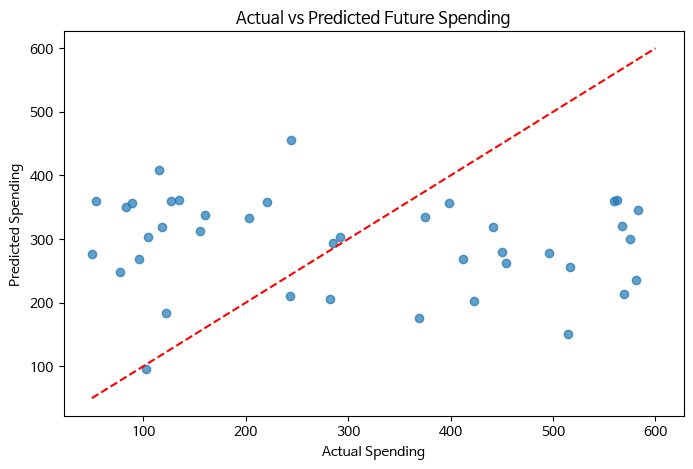

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 샘플 데이터 생성 (고객 행동 데이터)
np.random.seed(42)
num_customers = 200

data = pd.DataFrame({
    'Customer_ID': range(1, num_customers + 1),
    'Previous_Spending': np.random.randint(50, 500, size=num_customers),   # 이전 총 구매 금액 ($)
    'Visit_Frequency': np.random.randint(1, 20, size=num_customers),      # 웹사이트 방문 빈도 (월 단위)
    'Average_Order_Value': np.random.randint(10, 200, size=num_customers), # 평균 주문 금액 ($)
    'Discount_Used': np.random.choice([0, 1], size=num_customers),        # 할인 사용 여부 (0: 사용 안 함, 1: 사용)
    'Future_Spending': np.random.randint(50, 600, size=num_customers)     # 향후 한 달 동안의 예상 지출 ($)
})

# 2. 독립 변수(X)와 종속 변수(y) 설정
X = data[['Previous_Spending', 'Visit_Frequency', 'Average_Order_Value', 'Discount_Used']]
y = data['Future_Spending']

# 3. 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 랜덤 포레스트 회귀 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 예측 수행
y_pred = model.predict(X_test)

# 6. 모델 성능 평가
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# 7. 예측 결과 시각화
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Spending")
plt.ylabel("Predicted Spending")
plt.title("Actual vs Predicted Future Spending")
plt.plot([50, 600], [50, 600], color="red", linestyle="dashed")  # y=x 선
plt.show()

---

아래의 “랜덤 포레스트를 이용한 결혼 성공 예측” 코드를 참고해 본인만의 현실적인 컬럼으로 수정한 뒤 결혼성공 예측 모델을 개발해 보세요.


**시나리오**

한국에서 결혼 성공에 영향을 미치는 요소를 검토해 독립변수로 만들고 예측 모델을 개발한다.

이를 반영하여 다음과 같은 변수를 포함한 모델을 만든다.

1. **연애 기간(년)** - 연애한 기간이 길수록 결혼 가능성이 높을 가능성이 있음.
2. **경제력(연봉, 단위: 백만 원)** - 경제적 안정성이 결혼에 영향을 미침.
3. **성격 차이(점수, 0~100, 낮을수록 잘 맞음)** - 성격이 비슷할수록 결혼 성공 가능성이 높음.
4. **부모님 결혼 찬성 여부 (0: 반대, 1: 찬성)** - 한국에서는 가족의 의견이 결혼에 큰 영향을 미침.
5. **종교 차이 여부 (0: 차이 없음, 1: 차이 있음)** - 종교 차이가 결혼에 미치는 영향을 반영.
6. **취미 공유 정도(점수, 0~100, 높을수록 공유도가 높음)** - 취미 공유 여부가 커플의 관계 유지에 영향을 줄 수 있음.
7. **학력 (1: 고졸 이하, 2: 대졸, 3: 대학원 이상)** - 학력이 결혼 가능성에 미치는 영향을 반영.
8. **직장 안정성 (1: 불안정, 2: 보통, 3: 안정적)** - 직업 안정성이 결혼 결정에 중요한 요인일 수 있음.
9. **결혼 성공 여부 (1: 성공, 0: 실패)** - 실제 결혼 성공 여부.

정확도: 1.00

분류 보고서:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

새로운 연애 데이터에 대한 결혼 성공 예측 결과: 성공


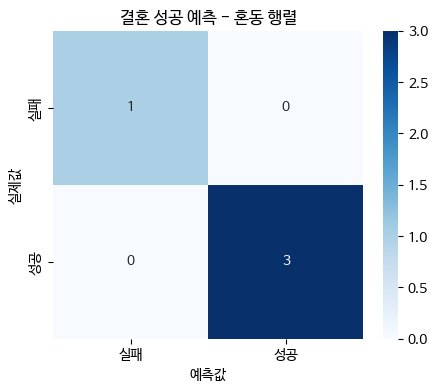

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. 한국 상황에 맞춘 연애 데이터 생성 (학력, 직장 추가)
data = pd.DataFrame({
    '연애기간(년)': [1, 2, 3, 5, 6, 1, 4, 2, 7, 3, 8, 6, 9, 10, 3, 5, 2, 7, 4, 6],
    '경제력(연봉:백만원)': [3000, 2500, 4000, 5000, 5500, 2000, 4200, 2800, 6000, 2300, 7000, 5000, 1800, 1500, 3200, 4800, 2700, 5800, 3500, 4600],
    '성격차이(점수)': [50, 40, 30, 70, 20, 90, 60, 30, 10, 80, 15, 25, 95, 100, 60, 40, 85, 20, 55, 45],
    '부모님찬성여부(0:반대,1:찬성)': [1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1],
    '종교차이여부(0:없음,1:있음)': [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0],
    '취미공유(점수)': [90, 60, 75, 80, 70, 40, 85, 55, 95, 50, 20, 80, 30, 10, 50, 90, 65, 85, 75, 60],
    '학력(1:고졸이하,2:대졸,3:대학원이상)': [2, 1, 2, 3, 3, 1, 2, 1, 3, 1, 3, 2, 1, 1, 2, 3, 1, 3, 2, 3],
    '직장안정성(1:불안정,2:보통,3:안정적)': [2, 1, 3, 3, 3, 1, 2, 1, 3, 1, 3, 3, 1, 1, 2, 3, 1, 3, 2, 3],
    '결혼성공(1:성공, 0:실패)': [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1]
})

# 2. 독립 변수(X)와 종속 변수(y) 설정
X = data[['연애기간(년)', '경제력(연봉:백만원)', '성격차이(점수)', '부모님찬성여부(0:반대,1:찬성)',
          '종교차이여부(0:없음,1:있음)', '취미공유(점수)', '학력(1:고졸이하,2:대졸,3:대학원이상)', '직장안정성(1:불안정,2:보통,3:안정적)']]
y = data['결혼성공(1:성공, 0:실패)']

# 3. 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 랜덤 포레스트 분류 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 테스트 데이터 예측 수행
y_pred = model.predict(X_test)

# 6. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도: {accuracy:.2f}")
print("\n분류 보고서:\n", classification_report(y_test, y_pred))

# 7. 새로운 데이터 입력 (연애 기간, 경제력, 성격 차이 등으로 결혼 성공 여부 예측)
new_data = pd.DataFrame({
    '연애기간(년)': [4],
    '경제력(연봉:백만원)': [4500],
    '성격차이(점수)': [35],
    '부모님찬성여부(0:반대,1:찬성)': [1],
    '종교차이여부(0:없음,1:있음)': [0],
    '취미공유(점수)': [80],
    '학력(1:고졸이하,2:대졸,3:대학원이상)': [2],
    '직장안정성(1:불안정,2:보통,3:안정적)': [3]
})

predicted_success = model.predict(new_data)
print(f"새로운 연애 데이터에 대한 결혼 성공 예측 결과: {'성공' if predicted_success[0] == 1 else '실패'}")

# 8. 혼동 행렬 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=["실패", "성공"], yticklabels=["실패", "성공"])
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.title("결혼 성공 예측 - 혼동 행렬")
plt.show()


위 “랜덤 포레스트를 이용한 결혼 성공 예측” 코드를 바탕으로 웹서비스 가능하도록 개발해 보세요.

**app.py**

In [ ]:
from flask import Flask, render_template, request
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

app = Flask(__name__)

# 1. 가상의 연애 데이터 생성 및 모델 학습
data = pd.DataFrame({
    '연애기간(년)': [1, 2, 3, 5, 6, 1, 4, 2, 7, 3, 8, 6, 9, 10, 3, 5, 2, 7, 4, 6],
    '경제력(연봉:백만원)': [3000, 2500, 4000, 5000, 5500, 2000, 4200, 2800, 6000, 2300, 7000, 5000, 1800, 1500, 3200, 4800, 2700, 5800, 3500, 4600],
    '성격차이(점수)': [50, 40, 30, 70, 20, 90, 60, 30, 10, 80, 15, 25, 95, 100, 60, 40, 85, 20, 55, 45],
    '부모님찬성여부(0:반대,1:찬성)': [1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1],
    '종교차이여부(0:없음,1:있음)': [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0],
    '취미공유(점수)': [90, 60, 75, 80, 70, 40, 85, 55, 95, 50, 20, 80, 30, 10, 50, 90, 65, 85, 75, 60],
    '학력(1:고졸이하,2:대졸,3:대학원이상)': [2, 1, 2, 3, 3, 1, 2, 1, 3, 1, 3, 2, 1, 1, 2, 3, 1, 3, 2, 3],
    '직장안정성(1:불안정,2:보통,3:안정적)': [2, 1, 3, 3, 3, 1, 2, 1, 3, 1, 3, 3, 1, 1, 2, 3, 1, 3, 2, 3],
    '결혼성공(1:성공, 0:실패)': [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1]
})

X = data.drop(columns=['결혼성공(1:성공, 0:실패)'])
y = data['결혼성공(1:성공, 0:실패)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Flask 라우트 설정
@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 사용자 입력 데이터 받기
        user_input = [int(request.form[key]) for key in X.columns]
        user_data = np.array(user_input).reshape(1, -1)

        # 예측 수행
        prediction = model.predict(user_data)[0]
        result = "결혼 성공 가능성이 높습니다! 💍🎉" if prediction == 1 else "결혼 성공 가능성이 낮습니다. 💔😢"

        return render_template('index.html', prediction_text=result)
    except Exception as e:
        return render_template('index.html', prediction_text=f"오류 발생: {e}")

if __name__ == '__main__':
    app.run(debug=True, host="0.0.0.0", port=5001)

**index.html**

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>결혼 성공 예측</title>
    <style>
        body {
            font-family: 'Arial', sans-serif;
            background: linear-gradient(120deg, #ff9a9e, #fad0c4);
            text-align: center;
            padding: 20px;
        }
        .container {
            max-width: 500px;
            margin: auto;
            background: white;
            padding: 20px;
            border-radius: 15px;
            box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);
        }
        h1 {
            color: #d63384;
        }
        label {
            font-weight: bold;
        }
        input {
            width: 100%;
            padding: 10px;
            margin: 5px 0;
            border: 1px solid #ddd;
            border-radius: 5px;
        }
        button {
            background-color: #ff758c;
            color: white;
            border: none;
            padding: 10px;
            width: 100%;
            border-radius: 5px;
            cursor: pointer;
        }
        button:hover {
            background-color: #ff5252;
        }
        .result {
            margin-top: 20px;
            font-size: 18px;
            font-weight: bold;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>💑 결혼 성공 예측 서비스 💍</h1>
        <form action="/predict" method="post">
            <label>연애 기간 (년)</label>
            <input type="number" name="연애기간(년)" required>

            <label>경제력 (연봉: 백만원)</label>
            <input type="number" name="경제력(연봉:백만원)" required>

            <label>성격 차이 (점수 0~100)</label>
            <input type="number" name="성격차이(점수)" required>

            <label>부모님 찬성 여부 (0: 반대, 1: 찬성)</label>
            <input type="number" name="부모님찬성여부(0:반대,1:찬성)" required>

            <label>종교 차이 여부 (0: 없음, 1: 있음)</label>
            <input type="number" name="종교차이여부(0:없음,1:있음)" required>

            <label>취미 공유 정도 (0~100)</label>
            <input type="number" name="취미공유(점수)" required>

            <label>학력 (1: 고졸 이하, 2: 대졸, 3: 대학원 이상)</label>
            <input type="number" name="학력(1:고졸이하,2:대졸,3:대학원이상)" required>

            <label>직장 안정성 (1: 불안정, 2: 보통, 3: 안정적)</label>
            <input type="number" name="직장안정성(1:불안정,2:보통,3:안정적)" required>

            <button type="submit">예측하기</button>
        </form>
        <div class="result">{{ prediction_text }}</div>
    </div>
</body>
</html>


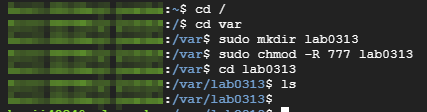

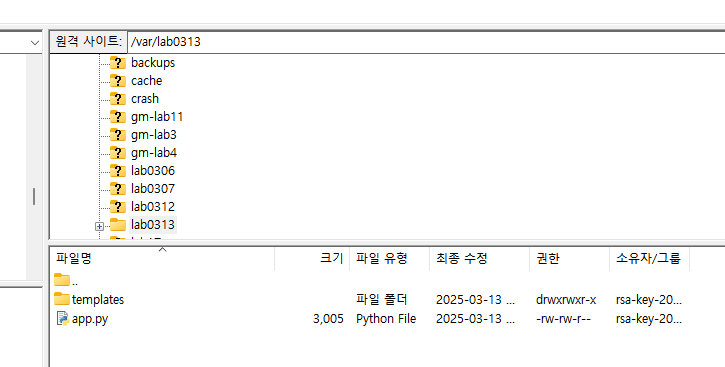

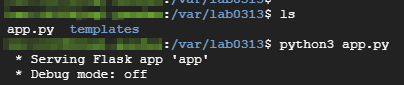

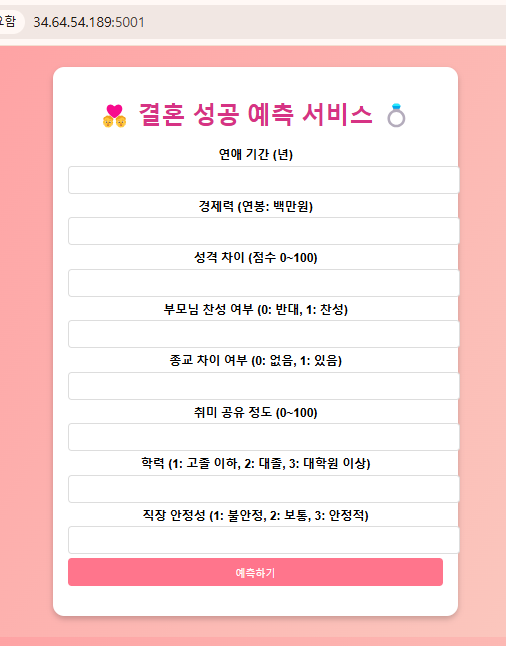

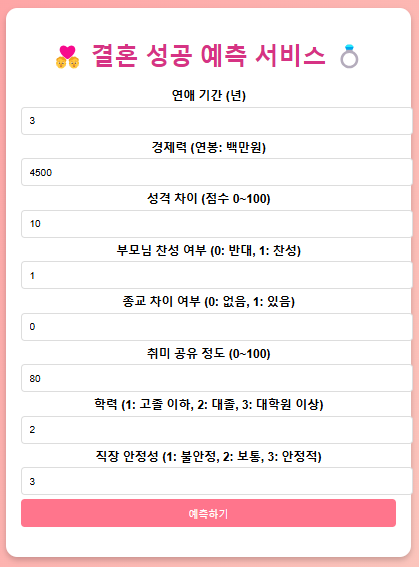 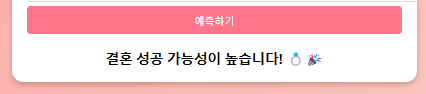



---

##**K-평균 군집화 (K-Means Clustering)**

K-평균 군집화(K-Means Clustering)는 데이터를 K개의 그룹으로 나누는 군집화(Clustering) 알고리즘이다. 주어진 데이터에서 각 데이터 포인트를 가장 가까운 중심(centroid)으로 할당하고, 중심을 반복적으로 업데이트하여 최적의 군집을 찾는다. 지도 학습(Supervised Learning)과 달리, K-평균 군집화는 비지도 학습(Unsupervised Learning) 방법에 속한다.


### **1. K-평균 군집화의 기본 개념**

K-평균 군집화는 다음과 같은 단계를 반복하여 최적의 군집을 형성한다.

1. 데이터에서 K개의 중심(centroid)을 무작위로 초기화한다.
2. 각 데이터 포인트를 가장 가까운 중심에 할당하여 군집을 형성한다.
3. 각 군집의 중심을 다시 계산하여 새로운 중심을 찾는다.
4. 새로운 중심을 기준으로 다시 군집을 할당하고, 중심이 더 이상 변화하지 않을 때까지 이 과정을 반복한다.

K-평균 알고리즘은 사용자가 미리 K값을 정해야 한다는 단점이 있으며, 최적의 K값을 찾기 위해 엘보우(Elbow) 기법과 실루엣(Silhouette) 점수와 같은 방법을 사용할 수 있다.


### **2. K-평균 군집화의 특징**

- 데이터가 사전에 라벨링되지 않은 경우에도 패턴을 발견하는 데 유용하다.
- 데이터가 구형(원형) 클러스터를 가질 때 효과적이며, 복잡한 형태의 클러스터에서는 성능이 저하될 수 있다.
- 초기 중심값의 설정에 따라 결과가 달라질 수 있으므로, 여러 번 실행하여 최적의 군집을 찾는 것이 중요하다.

### **3. K-평균 군집화의 장점과 단점**

장점

- 계산 속도가 빠르고 대규모 데이터에서도 비교적 효율적이다.
- 해석이 용이하며 직관적인 알고리즘이다.
- 특정 분야(이미지 분할, 고객 세분화 등)에서 널리 사용된다.

단점

- K값을 미리 설정해야 하며, 잘못된 K값 선택은 성능 저하를 초래할 수 있다.
- 원형 군집이 아닌 경우(예: 타원형 또는 비선형 구조) 성능이 낮을 수 있다.
- 이상치(Outlier)에 민감하여 중심값이 왜곡될 가능성이 있다.


### **4. K-평균 군집화 구현 (Python 예제)**

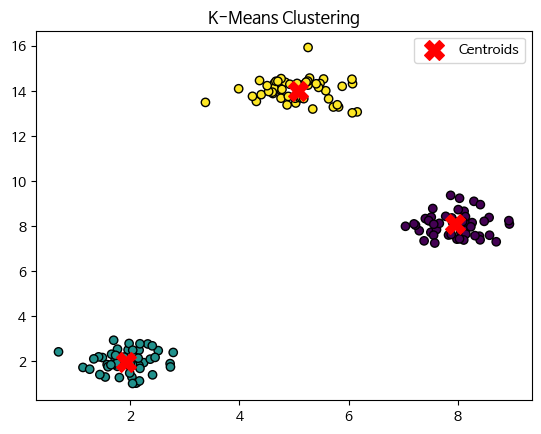

In [32]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(42)
X = np.vstack([
    np.random.normal(loc=[2, 2], scale=0.5, size=(50, 2)),
    np.random.normal(loc=[8, 8], scale=0.5, size=(50, 2)),
    np.random.normal(loc=[5, 14], scale=0.5, size=(50, 2))
])

# K-평균 군집화 수행
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# 결과 시각화
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', edgecolors='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.legend()
plt.title("K-Means Clustering")
plt.show()


### **5. K-평균 군집화의 활용 예제**

### **예제 1: 고객 세분화**

온라인 쇼핑몰에서 고객 데이터를 분석하여 비슷한 소비 패턴을 가진 고객들을 그룹화할 수 있다. 고객의 연간 구매 금액, 구매 빈도, 방문 횟수 등의 데이터를 기반으로 K-평균 군집화를 수행하면, VIP 고객, 일반 고객, 신규 고객 등의 그룹을 나눌 수 있다. 이를 통해 맞춤형 마케팅 전략을 수립할 수 있다.

In [33]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 샘플 고객 데이터 생성
data = {
    "Annual_Income": [15, 16, 17, 50, 52, 53, 100, 105, 110],
    "Spending_Score": [39, 40, 45, 60, 65, 70, 15, 18, 20]
}
df = pd.DataFrame(data)

# 데이터 정규화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# K-평균 군집화 수행
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print(df)


   Annual_Income  Spending_Score  Cluster
0             15              39        2
1             16              40        2
2             17              45        2
3             50              60        0
4             52              65        0
5             53              70        0
6            100              15        1
7            105              18        1
8            110              20        1


### **예제 2: 이미지 색상 압축**

이미지의 색상을 줄이는 데 K-평균 군집화를 사용할 수 있다. 예를 들어, 고해상도 이미지에서 1,000만 개의 색상을 단 16개의 색상으로 줄이면, 압축된 이미지를 생성할 수 있다.

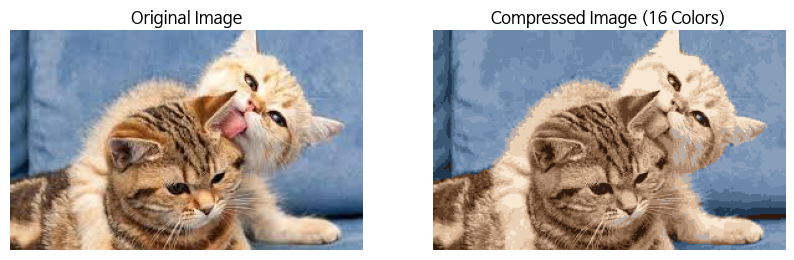

In [36]:
from sklearn.cluster import KMeans
from skimage import io
import numpy as np

# 이미지 로드
image = io.imread("cat.jpeg")
pixels = image.reshape(-1, 3)

# K-평균 군집화 적용
kmeans = KMeans(n_clusters=16, random_state=42)
kmeans.fit(pixels)
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]
compressed_image = compressed_pixels.reshape(image.shape)

# 압축된 이미지 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed_image.astype(np.uint8))
plt.title("Compressed Image (16 Colors)")
plt.axis("off")

plt.show()


이 코드는 K-평균 군집화를 사용하여 원본 이미지의 색상을 16개의 주요 색상으로 줄이는 예제이다.

### **예제 3: 이상치 탐지**

K-평균 군집화를 사용하여 정상적인 데이터 포인트와 이상치를 구별할 수 있다. 예를 들어, 은행 거래 데이터를 분석하여 비정상적인 거래(사기)를 탐지하는 데 활용할 수 있다.

In [40]:
import numpy as np

# 샘플 거래 데이터 생성
transactions = np.array([
    [50, 1], [60, 1], [55, 2], [700, 5], [58, 2], [62, 1], [750, 5], [65, 2]
])

# K-평균 군집화 적용
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(transactions)

# 이상치 탐지
outliers = transactions[labels == labels.max()]

print("Detected Outliers:\n", outliers)


Detected Outliers:
 [[700   5]
 [750   5]]


### **최적의 K값을 찾는 방법: 엘보우 기법과 실루엣 점수**

K-평균(K-Means) 알고리즘은 군집의 개수(K)를 사용자가 미리 설정해야 한다는 단점이 있다. 따라서 최적의 K값을 찾기 위해 **엘보우(Elbow) 기법**과 **실루엣(Silhouette) 점수**를 활용할 수 있다.

- **엘보우 기법(Elbow Method)**: K값에 따른 군집 내 변동 값(Inertia)을 계산하여, 그래프의 기울기가 급격히 완만해지는 지점(엘보우 포인트)을 최적의 K값으로 선택한다.
- **실루엣 점수(Silhouette Score)**: 각 데이터 포인트가 자신의 군집과 얼마나 밀접하게 묶여 있으며, 다른 군집과는 얼마나 분리되어 있는지를 평가하는 지표이다. 실루엣 점수가 높을수록 군집화가 잘 되어 있음을 의미한다.

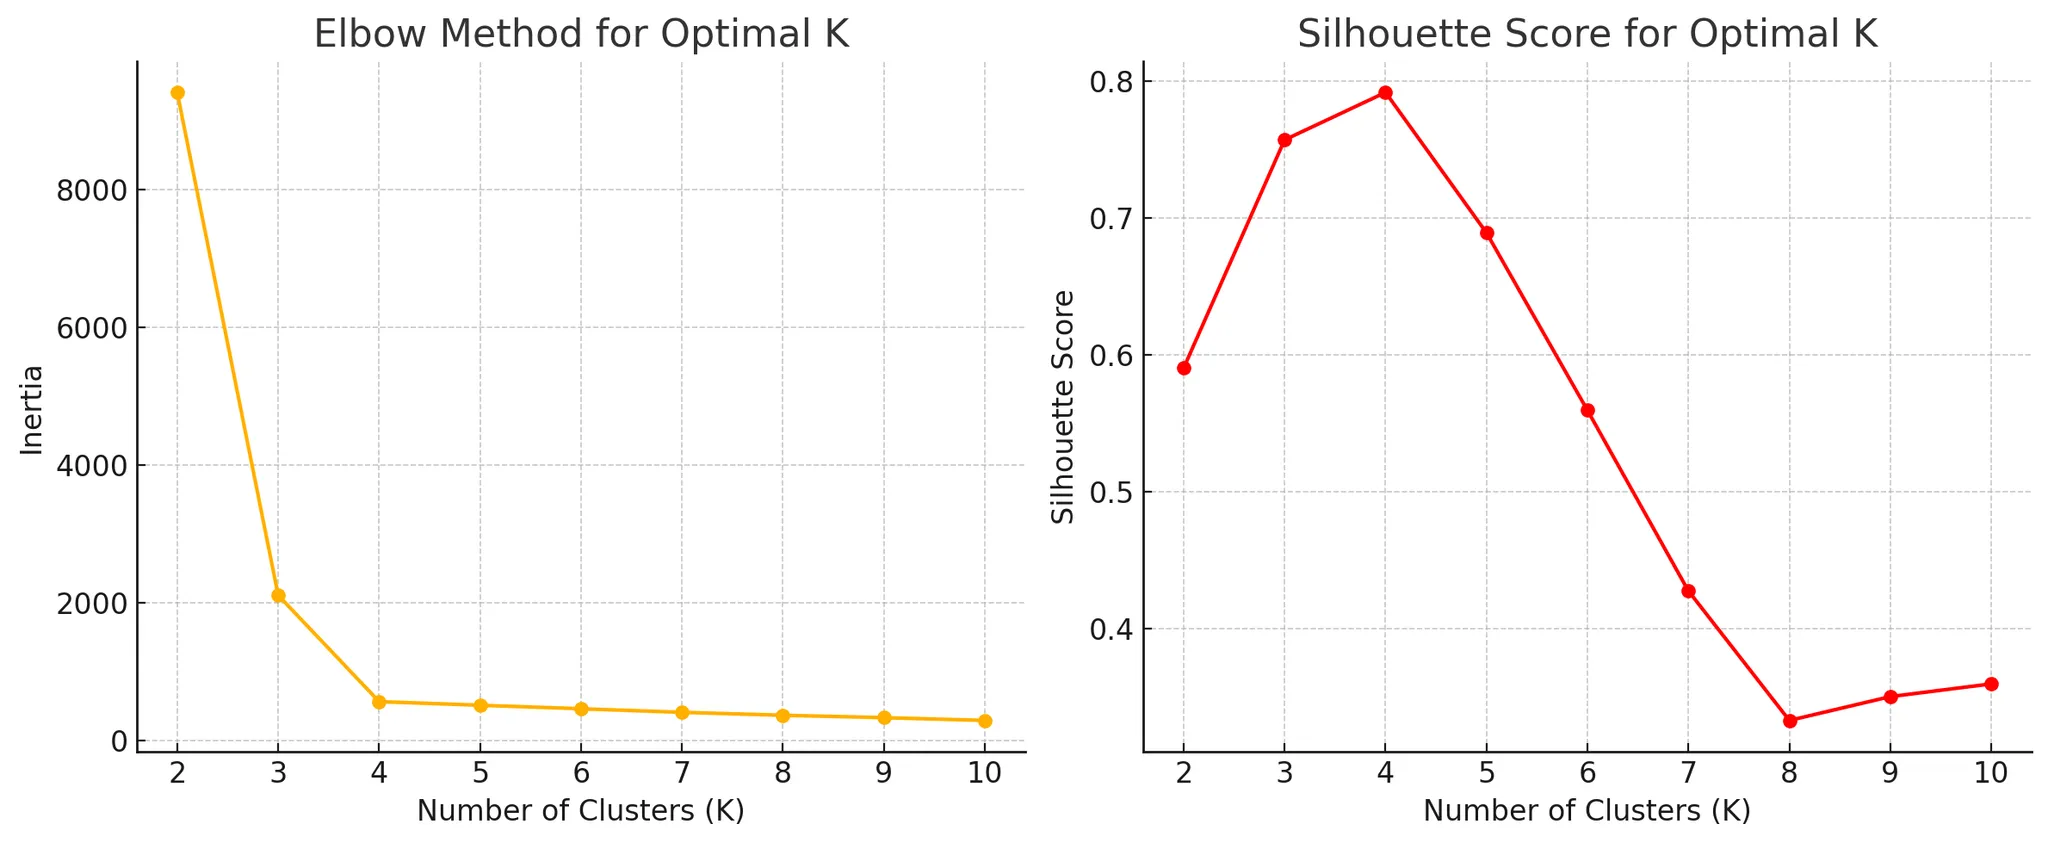

1. 데이터 생성

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# 샘플 데이터 생성
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

2. 엘보우 기법을 이용한 최적 K값 찾기

이 코드를 실행하면 엘보우 차트가 생성되며, 곡선이 급격히 꺾이는 지점이 최적의 K값이 된다.

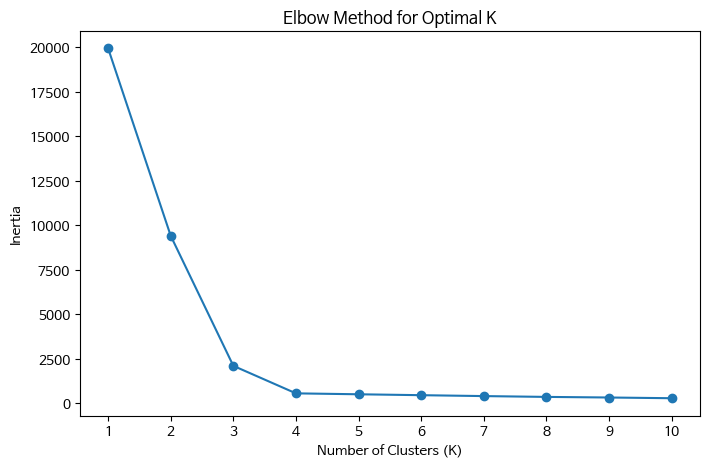

In [38]:
# K 값별 관성(Inertia) 저장
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 엘보우 차트 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_range)
plt.show()

3. 실루엣 점수를 이용한 최적 K값 찾기

이 코드를 실행하면 실루엣 점수 차트가 생성되며, 점수가 가장 높은 K값이 최적의 클러스터 개수가 된다.

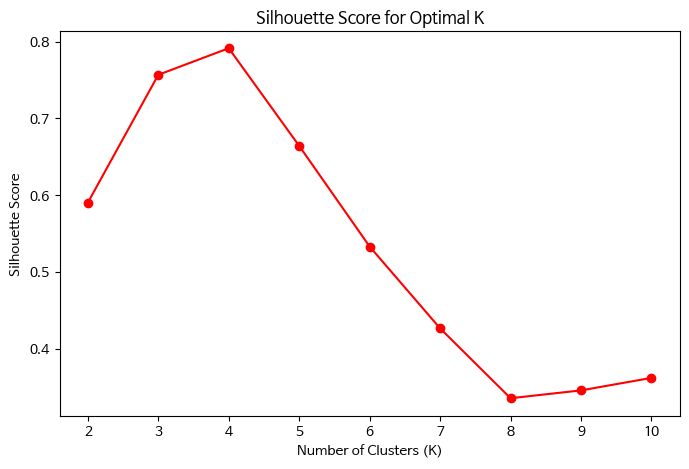

In [39]:
# K 값별 실루엣 점수 저장
silhouette_scores = []

for k in range(2, 11):  # 실루엣 점수는 최소 2개 이상의 클러스터가 필요
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

# 실루엣 점수 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='red')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.xticks(range(2, 11))
plt.show()

### 4. 결론

- **엘보우 기법**을 통해 K값이 4에서 급격히 기울기가 완만해지는 것을 확인할 수 있다.
- **실루엣 점수**를 보면, 가장 높은 점수를 갖는 K값이 최적의 군집 개수로 판단할 수 있다.